# Capstone Project - Cards Fraud Detection #

# Summary #
We are going to be working on a Cards Payment Fraud Classification problem using real world data from Vesta corporation. 
The data has been made available freely on Kaggle(a user login is required to downlad the datasets). 
This data was presented in a data science competition held 7 years ago.
The data comes from Vesta's real-world e-commerce transactions and contains a wide range of features from device type to product features.

## 1. Load and merge data ##
Goal: Read the CSVs, inspect shapes, and join train_transaction and train_identity on TransactionID

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Set a path if running locally; in Kaggle these files can be found at https://www.kaggle.com/c/ieee-fraud-detection/data
DATA_PATH = "data/ieee-fraud-detection"

train_trans = pd.read_csv(f"{DATA_PATH}/train_transaction.csv")
train_id = pd.read_csv(f"{DATA_PATH}/train_identity.csv")

test_trans = pd.read_csv(f"{DATA_PATH}/test_transaction.csv")
test_id = pd.read_csv(f"{DATA_PATH}/test_identity.csv")

print("Train transaction shape:", train_trans.shape)
print("Train identity shape:", train_id.shape)
print("Test transaction shape:", test_trans.shape)
print("Test identity shape:", test_id.shape)

# Merge train
train = train_trans.merge(train_id, how="left", on="TransactionID")
print("Merged train shape:", train.shape)

# Merge test (for later consistency checks, not used in EDA with target)
test = test_trans.merge(test_id, how="left", on="TransactionID")
print("Merged test shape:", test.shape)

# Inspect columns
train.head()

Train transaction shape: (590540, 394)
Train identity shape: (144233, 41)
Test transaction shape: (506691, 393)
Test identity shape: (141907, 41)
Merged train shape: (590540, 434)
Merged test shape: (506691, 433)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## 2. Basic data overview and target analysis ##
Goal: Understand the target distribution (isFraud), numerical vs categorical variables, and basic statistics.

Fraud counts:
 isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate: 3.4990%


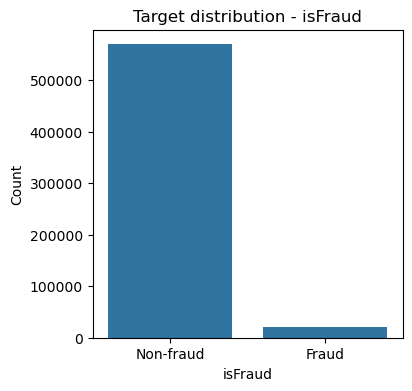

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
card2,581607.0,3.625555e+02,1.577932e+02,100.000,214.000,361.000,512.00,6.000000e+02
card3,588975.0,1.531949e+02,1.133644e+01,100.000,150.000,150.000,150.00,2.310000e+02
card5,586281.0,1.992789e+02,4.124445e+01,100.000,166.000,226.000,226.00,2.370000e+02
addr1,524834.0,2.907338e+02,1.017411e+02,100.000,204.000,299.000,330.00,5.400000e+02
addr2,524834.0,8.680063e+01,2.690623e+00,10.000,87.000,87.000,87.00,1.020000e+02


In [3]:
# Target distribution
fraud_counts = train['isFraud'].value_counts()
fraud_rate = fraud_counts[1] / fraud_counts.sum()

print("Fraud counts:\n", fraud_counts)
print(f"Fraud rate: {fraud_rate:.4%}")

plt.figure(figsize=(4,4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values)
plt.xticks([0,1], ['Non-fraud', 'Fraud'])
plt.title("Target distribution - isFraud")
plt.ylabel("Count")
plt.savefig("images/TargetDistribution_isFraud.png")
plt.show()

# Quick info and basic describe
train.info()

# Basic descriptive stats for numeric columns
train.describe().T.head(20)

List numeric vs catergorical columns:

In [4]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 403
Categorical columns: 31


## 3. Missing values and data types ##
Goal: Understand which features are sparse and may need special treatment

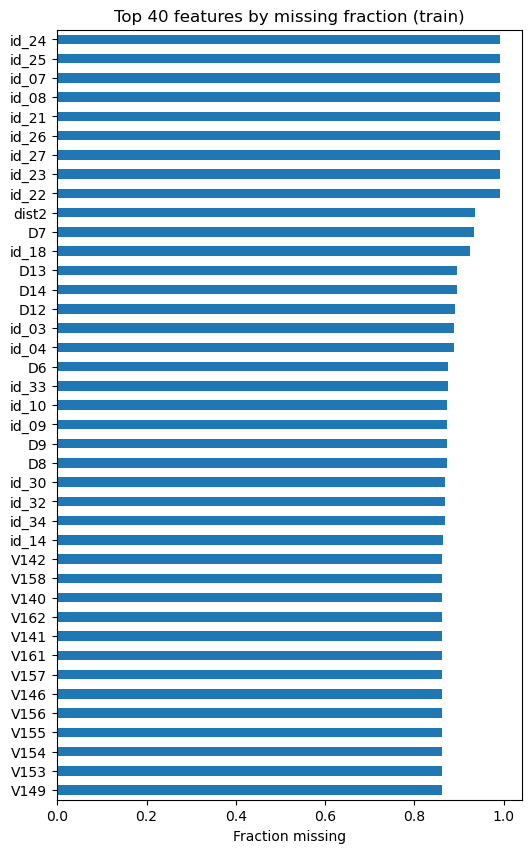

In [5]:
# Missing value fraction per column
missing_train = train.isnull().mean().sort_values(ascending=False)
missing_train.head(40)

plt.figure(figsize=(6,10))
missing_train.head(40).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 40 features by missing fraction (train)")
plt.xlabel("Fraction missing")
plt.savefig("images/Top40FeaturesByMissingFraction(train).png")
plt.show()

In [6]:
# Export to a missingness table
missing_df = missing_train.reset_index()
missing_df.columns = ['feature', 'missing_fraction']
missing_df.to_csv("output/missing_values_train.csv", index=False)

We also compare missingness between train and test to spot leakage‑prone features.
This helps identify columns where train/test behaviour differs strongly.

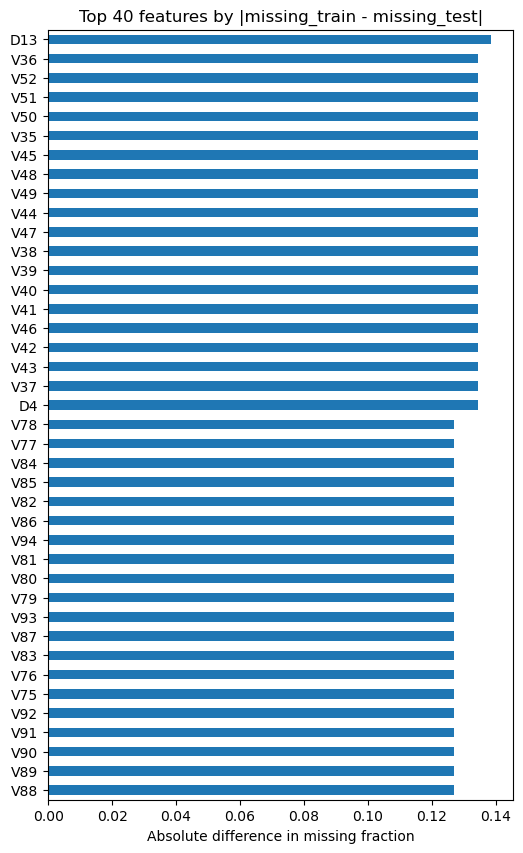

In [7]:
missing_test = test.isnull().mean()

missing_diff = (missing_train - missing_test).abs().sort_values(ascending=False)
missing_diff.head(30)

plt.figure(figsize=(6,10))
missing_diff.head(40).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 40 features by |missing_train - missing_test|")
plt.xlabel("Absolute difference in missing fraction")
plt.savefig("images/Top40FeaturesBy(missing_train-missing_test).png")
plt.show()

## 4. Univariate analysis: key groups of features ##
The IEEE‑CIS features are naturally grouped: transaction, card, address, email, D*, C*, M*, id*, device, V*. We’ll inspect a few representative variables in each group.

### 4.1 Transaction amount and time ###

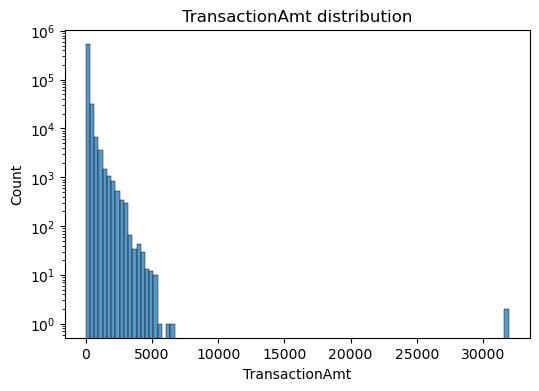

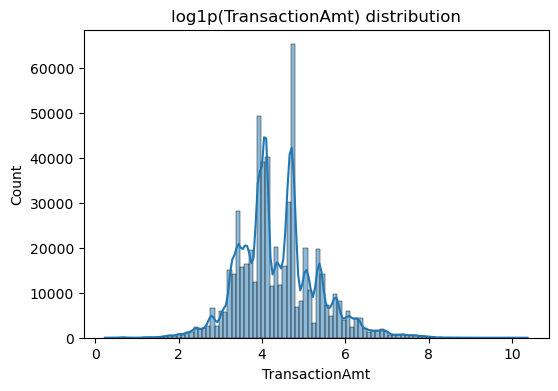

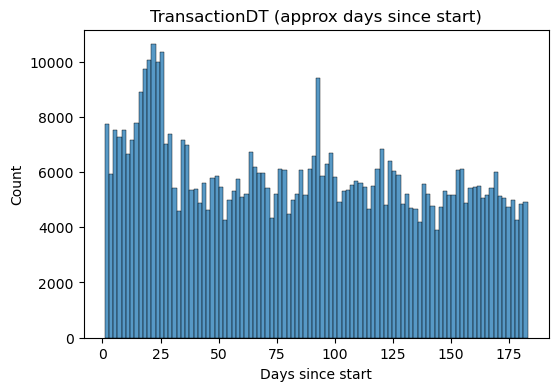

In [8]:
# TransactionAmt distribution (log scale because of heavy tail)
plt.figure(figsize=(6,4))
sns.histplot(train['TransactionAmt'], bins=100, kde=False)
plt.yscale('log')
plt.title("TransactionAmt distribution")
plt.savefig("images/Univariate_TransactionAmtDistribution.png")
plt.show()

# Log-transformed
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(train['TransactionAmt']), bins=100, kde=True)
plt.title("log1p(TransactionAmt) distribution")
plt.savefig("images/Univariate_Log1pTransactionAmtDistribution.png")
plt.show()

# TransactionDT (relative time, in seconds)
plt.figure(figsize=(6,4))
sns.histplot(train['TransactionDT']/24/60/60, bins=100, kde=False)
plt.title("TransactionDT (approx days since start)")
plt.xlabel("Days since start")
plt.savefig("images/Univariate_TransactionDTDaySinceStart.png")
plt.show()

### 4.2 Card features (card1–card6) ###

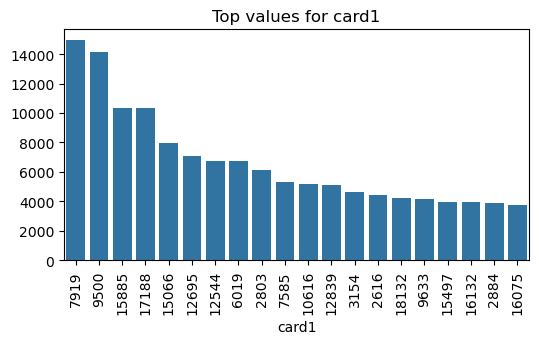

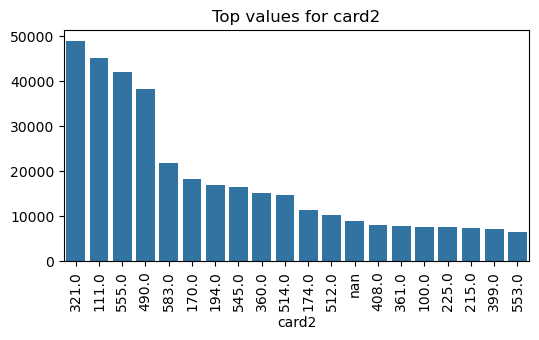

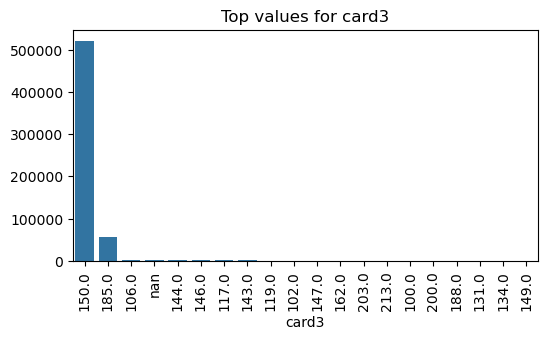

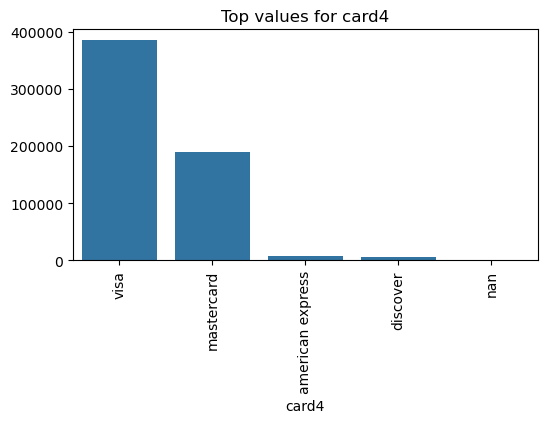

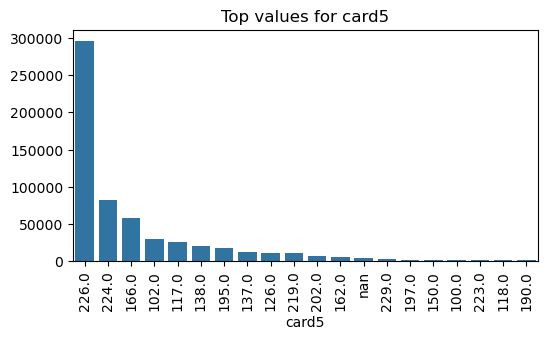

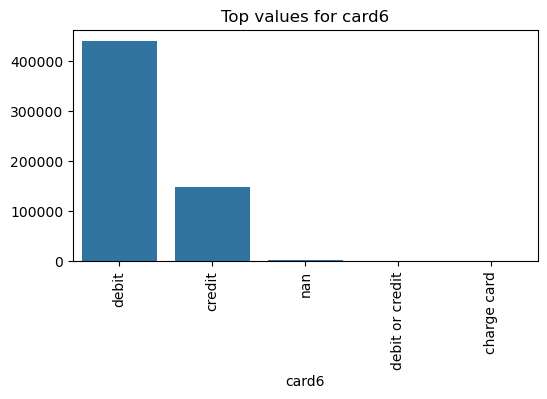

In [11]:
card_cols = [c for c in train_trans.columns if c.startswith('card')]
card_cols

for c in card_cols:
    plt.figure(figsize=(6,3))
    value_counts = train[c].value_counts(dropna=False).head(20)
    sns.barplot(x=value_counts.index.astype(str), y=value_counts.values)
    plt.xticks(rotation=90)
    plt.title(f"Top values for {c}")
    plt.savefig(f"images/TopValuesFor-{c}.png")
    plt.show()

### 4.3 Address and email ###

['addr1', 'addr2']


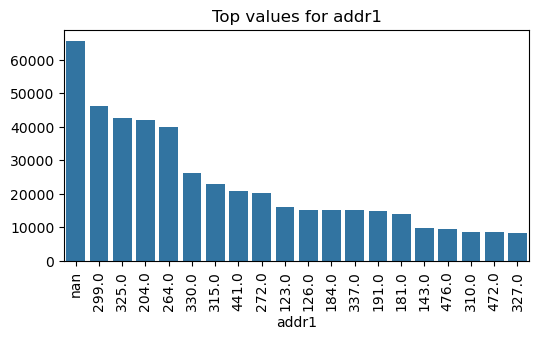

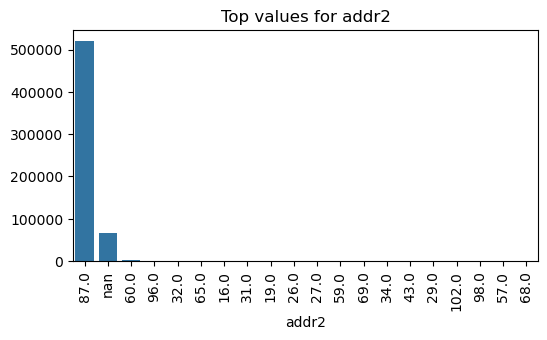

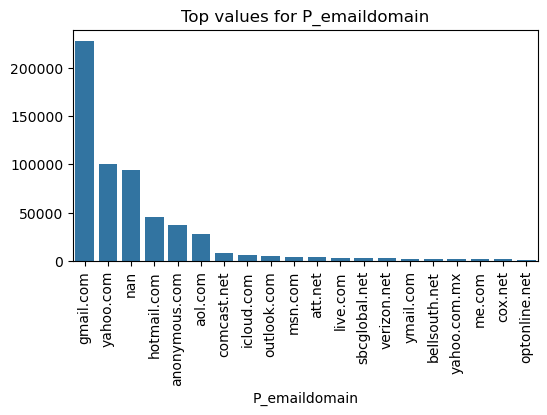

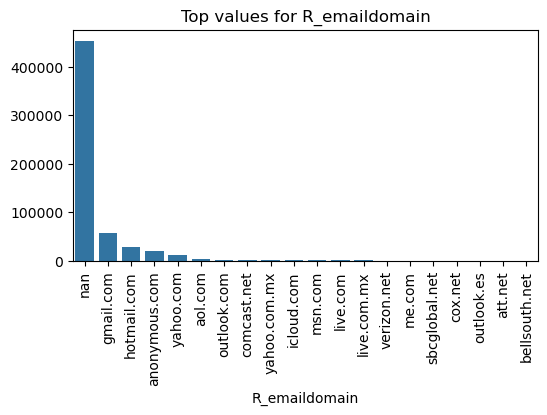

In [13]:
addr_cols = [c for c in train_trans.columns if c.startswith('addr')]
print(addr_cols)

for c in addr_cols + ['P_emaildomain', 'R_emaildomain']:
    if c in train.columns:
        vc = train[c].value_counts(dropna=False).head(20)
        plt.figure(figsize=(6,3))
        sns.barplot(x=vc.index.astype(str), y=vc.values)
        plt.xticks(rotation=90)
        plt.title(f"Top values for {c}")
        plt.savefig(f"images/TopValuesFor-{c}.png")
        plt.show()

### 4.4 Identity / device features ###

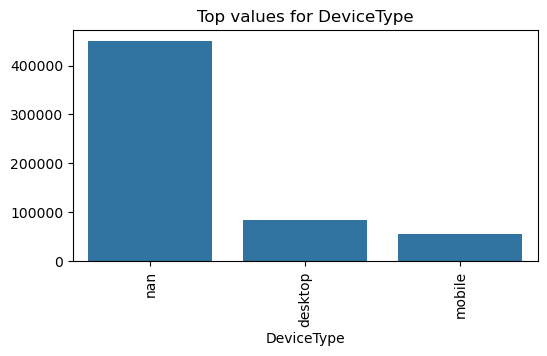

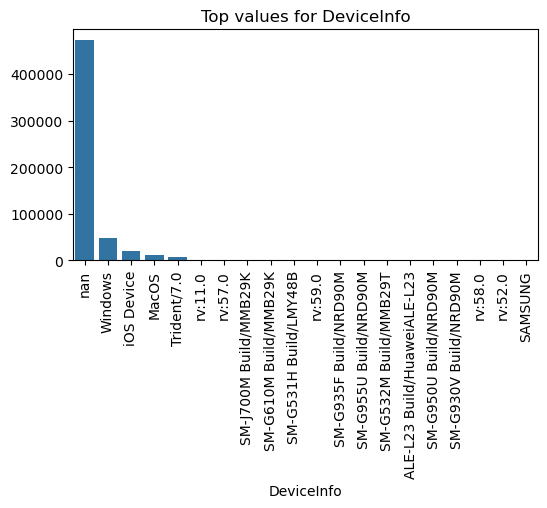

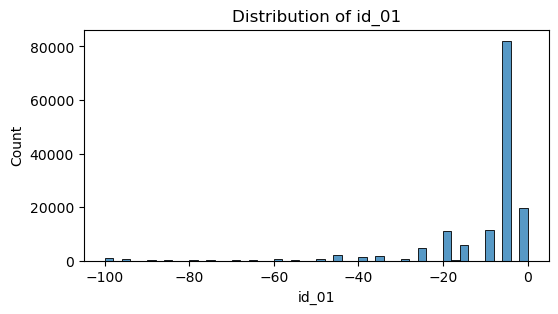

In [14]:
id_cols = train_id.columns.drop(['TransactionID']) if 'TransactionID' in train_id.columns else train_id.columns

# Example: DeviceType, DeviceInfo, id_01
for c in ['DeviceType', 'DeviceInfo', 'id_01']:
    if c in train.columns:
        if train[c].dtype == 'O':
            vc = train[c].value_counts(dropna=False).head(20)
            plt.figure(figsize=(6,3))
            sns.barplot(x=vc.index.astype(str), y=vc.values)
            plt.xticks(rotation=90)
            plt.title(f"Top values for {c}")
            plt.savefig(f"images/TopValuesFor-{c}.png")
            plt.show()
        else:
            plt.figure(figsize=(6,3))
            sns.histplot(train[c], bins=50, kde=False)
            plt.title(f"Distribution of {c}")
            plt.savefig(f"images/DistributionOf-{c}.png")
            plt.show()

## 5. Fraud vs non‑fraud comparisons (bivariate) ##
Now we compare distributions conditioned on isFraud to spot discriminative patterns.

### 5.1 Transaction amount by fraud label ###

For more stable plots, use log1p:

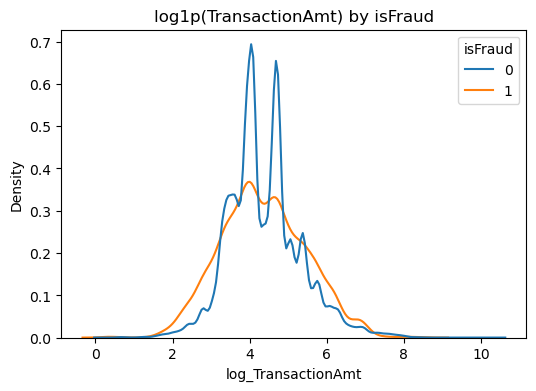

In [15]:
sample = train.sample(150000, random_state=42)
sample['log_TransactionAmt'] = np.log1p(sample['TransactionAmt'])

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sample,
    x='log_TransactionAmt',
    hue='isFraud',
    common_norm=False
)
plt.title("log1p(TransactionAmt) by isFraud")
plt.savefig("images/log1pTransactionAmtBy_isFraud.png")
plt.show()

## 5.2 Fraud rate by card and email domains ##

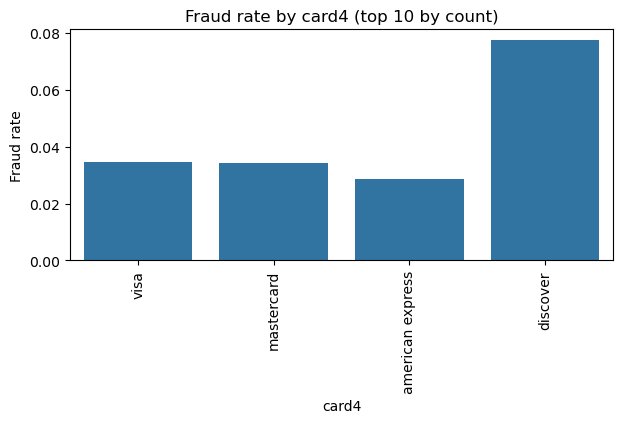

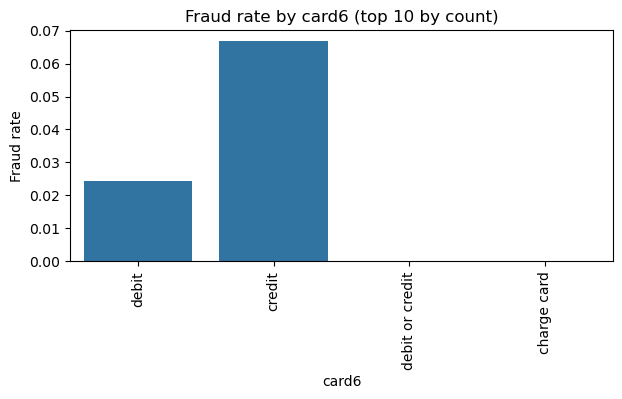

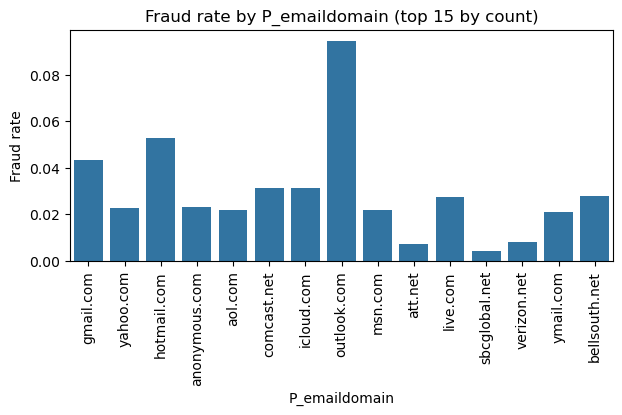

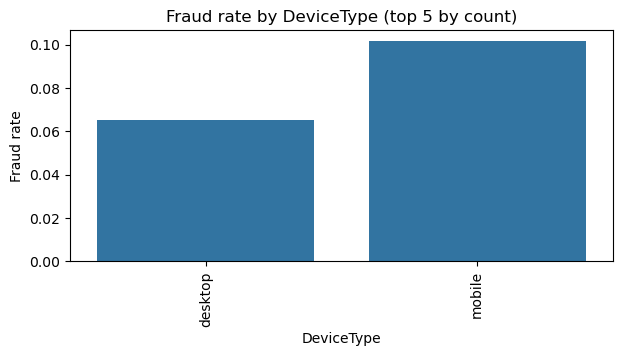

,DeviceType,mean,count
0,desktop,0.065215,85165
1,mobile,0.101662,55645


In [16]:
def fraud_rate_by_feature(df, feature, top_n=10):
    tmp = df.groupby(feature)['isFraud'].agg(['mean', 'count']).sort_values('count', ascending=False).head(top_n)
    tmp = tmp.reset_index()
    plt.figure(figsize=(7,3))
    sns.barplot(data=tmp, x=feature, y='mean')
    plt.xticks(rotation=90)
    plt.ylabel('Fraud rate')
    plt.title(f"Fraud rate by {feature} (top {top_n} by count)")
    plt.savefig(f"images/FraudRateBy_{feature}_(top_{top_n}_ByCount).png")
    plt.show()
    return tmp

fraud_rate_by_feature(train, 'card4', top_n=10)
fraud_rate_by_feature(train, 'card6', top_n=10)
fraud_rate_by_feature(train, 'P_emaildomain', top_n=15)
fraud_rate_by_feature(train, 'DeviceType', top_n=5)

## 5.3 Time‑based patterns ##
Convert TransactionDT to approximate day and hour and examine fraud rate across these.

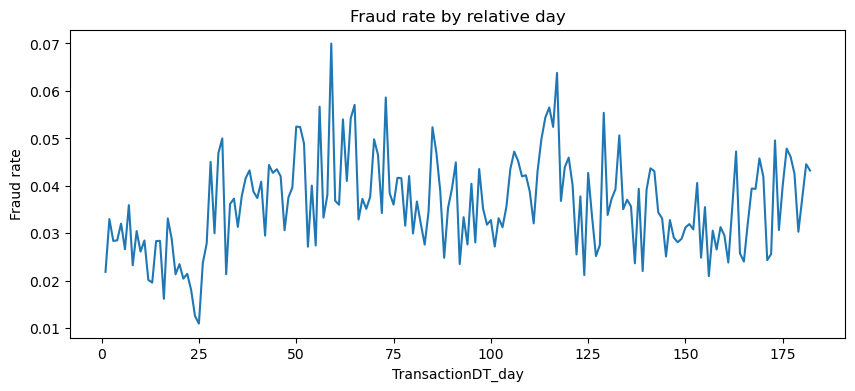

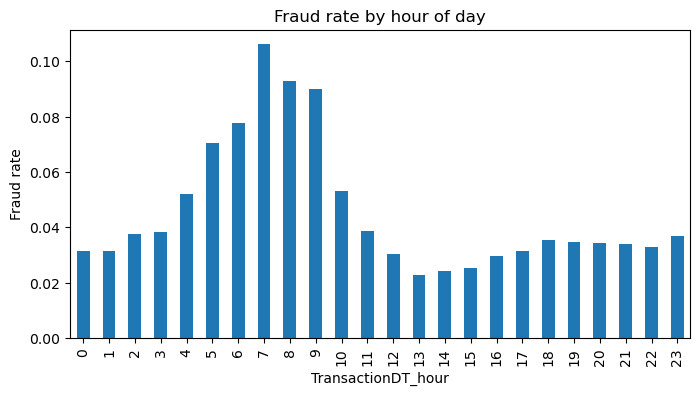

In [17]:
# Make sure we don't re-create columns if they already exist
if 'TransactionDT_day' not in train.columns:
    train['TransactionDT_days'] = train['TransactionDT'] / (24*60*60)
    train['TransactionDT_day'] = train['TransactionDT_days'].astype(int)
    train['TransactionDT_hour'] = (train['TransactionDT'] // 3600) % 24

# Fraud rate by day
day_stats = train.groupby('TransactionDT_day')['isFraud'].agg(['mean','count'])

plt.figure(figsize=(10,4))
day_stats['mean'].plot()
plt.title("Fraud rate by relative day")
plt.ylabel("Fraud rate")
plt.show()

# Fraud rate by hour of day
hour_stats = train.groupby('TransactionDT_hour')['isFraud'].agg(['mean','count'])

plt.figure(figsize=(8,4))
hour_stats['mean'].plot(kind='bar')
plt.title("Fraud rate by hour of day")
plt.ylabel("Fraud rate")
plt.savefig("images/FraudRateByHourOfDay.png")
plt.show()

## 5.4  Fraud rate by categorical features ##

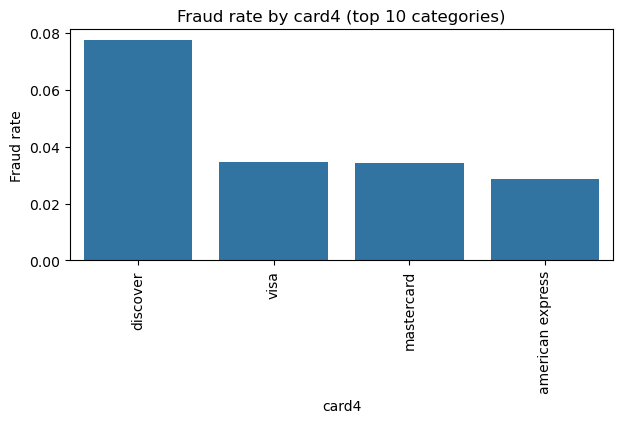

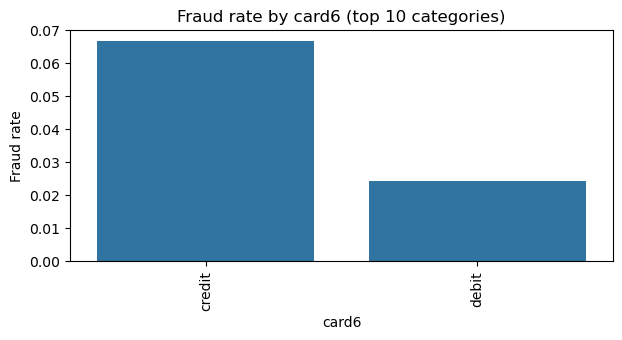

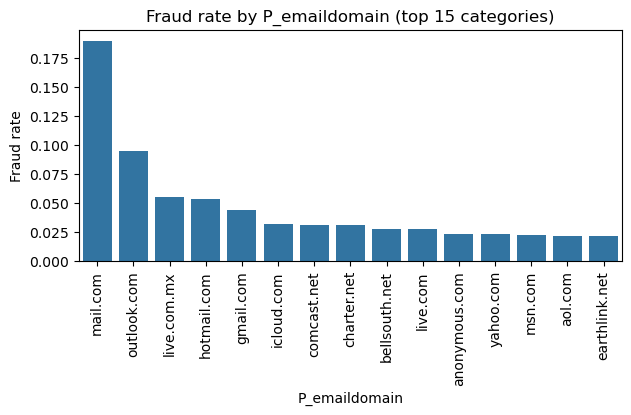

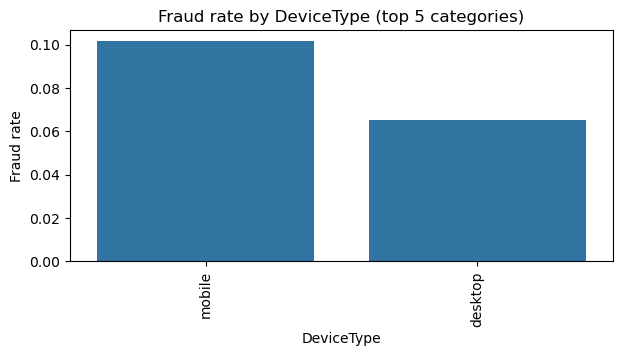

In [18]:
def fraud_rate_table(df, feature, min_count=200):
    # Group by feature and compute fraud rate + count
    tmp = df.groupby(feature)['isFraud'].agg(['mean','count'])
    tmp = tmp[tmp['count'] >= min_count].sort_values('mean', ascending=False)
    return tmp

def plot_fraud_rate_bar(df, feature, top_n=10, min_count=200):
    tmp = fraud_rate_table(df, feature, min_count=min_count).head(top_n)
    if tmp.empty:
        print(f"No categories with count >= {min_count} for {feature}")
        return tmp
    plt.figure(figsize=(7,3))
    sns.barplot(x=tmp.index.astype(str), y=tmp['mean'])
    plt.xticks(rotation=90)
    plt.ylabel('Fraud rate')
    plt.title(f"Fraud rate by {feature} (top {top_n} categories)")
    plt.savefig(f"images/FraudRateBy_{feature}_(top_{top_n}_categories).png")
    plt.show()
    return tmp

# Examples
card4_fr = plot_fraud_rate_bar(train, 'card4', top_n=10, min_count=500)
card6_fr = plot_fraud_rate_bar(train, 'card6', top_n=10, min_count=500)
p_email_fr = plot_fraud_rate_bar(train, 'P_emaildomain', top_n=15, min_count=500)
device_fr  = plot_fraud_rate_bar(train, 'DeviceType', top_n=5, min_count=500)

In [19]:
# Save these
card4_fr.to_csv("output/fraud_rate_card4.csv")
p_email_fr.to_csv("output/fraud_rate_P_emaildomain.csv")

### Numerical "D" and "C" features vs fraud.
These often capture delays and counts; some may be strong predictors
We verify these to see which show clear separation

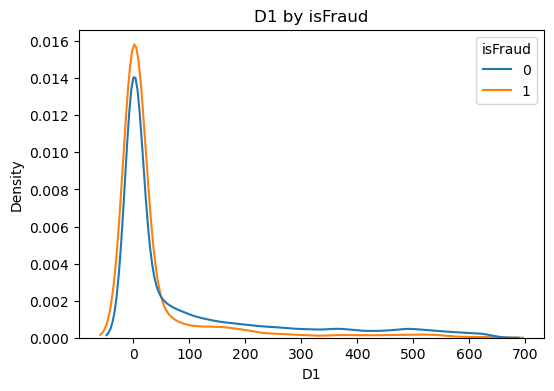

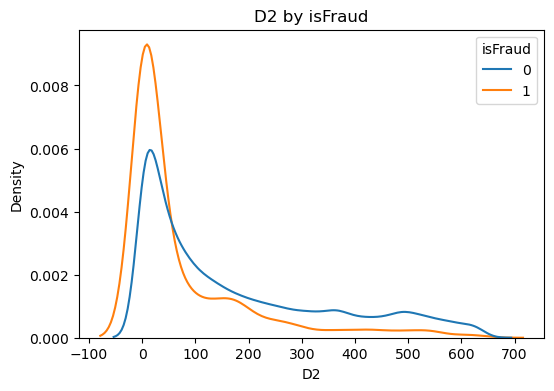

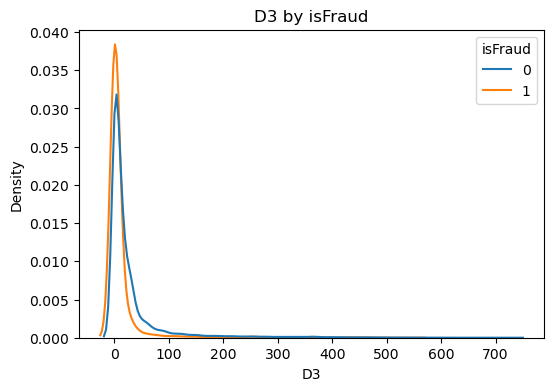

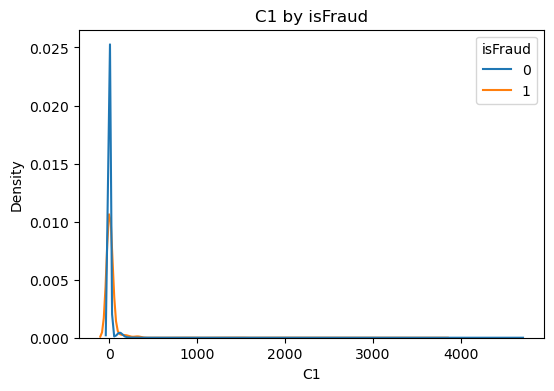

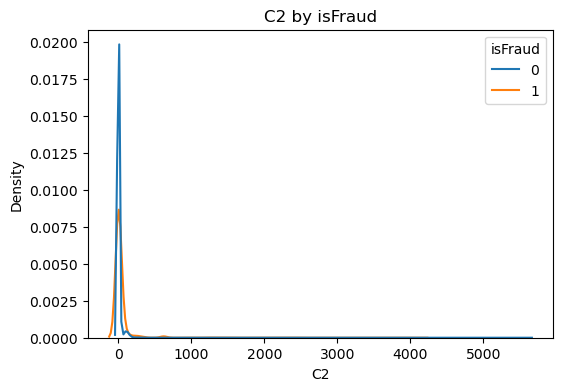

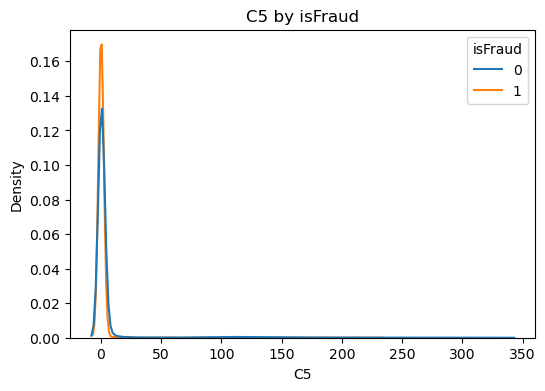

In [20]:
num_for_kde = ['D1', 'D2', 'D3', 'C1', 'C2', 'C5']
for col in num_for_kde:
    if col in train.columns:
        plt.figure(figsize=(6,4))
        sns.kdeplot(
            data=train[~train[col].isnull()].sample(100000, random_state=42),
            x=col,
            hue='isFraud',
            common_norm=False
        )
        plt.title(f"{col} by isFraud")
        plt.savefig(f"images/{col}_By_isFraud.png")
        plt.show()

## 6. Behaviour‑style / velocity EDA ##
Here you start to approximate the behavioural ideas you described (velocity, deviations) but still treat them as EDA, not final features.

Example: transaction count per card over a time window.

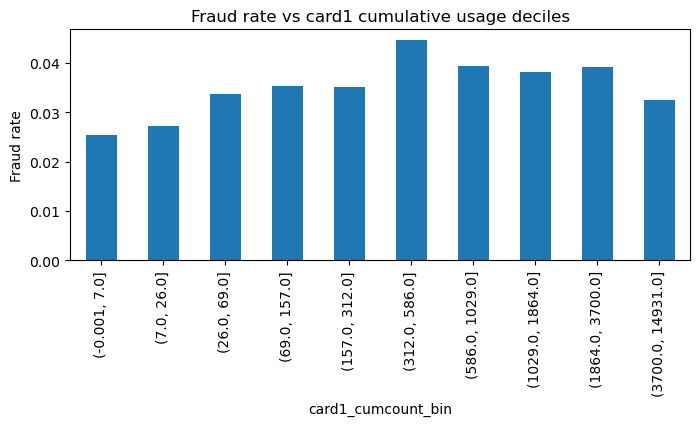

In [21]:
df_beh = train[['TransactionID', 'TransactionDT', 'isFraud', 'card1', 'TransactionAmt']].copy()
df_beh = df_beh.sort_values(['card1', 'TransactionDT'])

# Cumulative count per card (proxy for experience / usage)
df_beh['card1_cumcount'] = df_beh.groupby('card1').cumcount()

# Bucket into deciles
df_beh['card1_cumcount_bin'] = pd.qcut(df_beh['card1_cumcount'], 10, duplicates='drop')

fraud_by_cumcount = df_beh.groupby('card1_cumcount_bin', observed=True)['isFraud'].mean()

plt.figure(figsize=(8,3))
fraud_by_cumcount.plot(kind='bar')
plt.title("Fraud rate vs card1 cumulative usage deciles")
plt.ylabel("Fraud rate")
plt.savefig("images/FraudRateVsCard1_CumulativeUsageDeciles.png")
plt.show()

Also check average amount per card and deviations. This shows whether fraud tends to be unusually high/low relative to a card’s baseline.

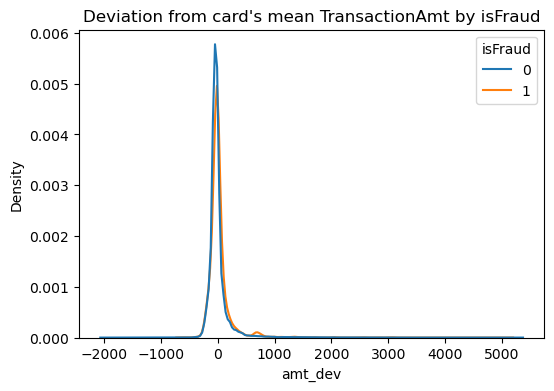

In [22]:
df_beh['card1_mean_amt'] = df_beh.groupby('card1')['TransactionAmt'].transform('mean')
df_beh['amt_dev'] = df_beh['TransactionAmt'] - df_beh['card1_mean_amt']

sample_beh = df_beh.sample(150000, random_state=42)

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sample_beh,
    x='amt_dev',
    hue='isFraud',
    common_norm=False
)
plt.title("Deviation from card's mean TransactionAmt by isFraud")
plt.savefig("images/DeviationFromCardMeanTransactionAmt_By_isFraud.png")
plt.show()

## 7. Class imbalance inspection ##
We already looked at the target proportion; now check how this affects metrics later and where fraud sits in feature space.

A quick PCA view on a subset of numeric features for intuition. This helps see whether fraud is linearly separable or heavily overlapping in the chosen projection.

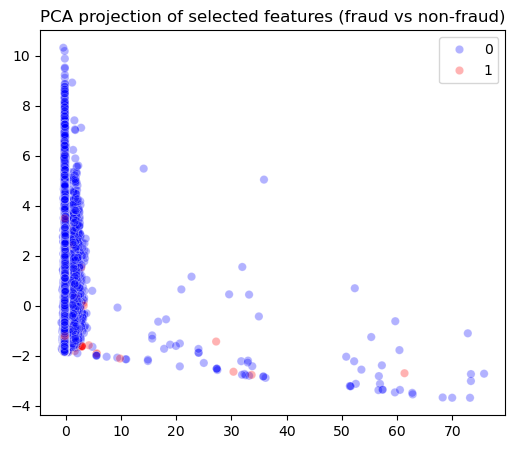

In [23]:
# Use a small numeric subset (e.g., TransactionAmt, D1-D5, C1-C5)
subset_cols = ['TransactionAmt'] + [c for c in train.columns if c.startswith('D')][:5] + [c for c in train.columns if c.startswith('C')][:5]
subset_cols = [c for c in subset_cols if c in train.columns]

sample = train[subset_cols + ['isFraud']].dropna().sample(50000, random_state=42)

X = sample[subset_cols].values
y = sample['isFraud'].values

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, alpha=0.3, palette={0:'blue',1:'red'})
plt.title("PCA projection of selected features (fraud vs non-fraud)")
plt.savefig("images/PCAProjectionOfSelectedFeatures_(fraud_vs_non-fraud).png")
plt.show()

## 8 Correlation heatmaps ##
because IEEE‑CIS has 400+ features, ywe will want to be selective, otherwise the heatmap becomes unreadable and slow to compute.

### 8.1 General Correlation heatmap helper ###

In [24]:
def plot_corr_heatmap(corr, title="Correlation matrix", vmax=0.3):
    mask = np.triu(np.ones_like(corr, dtype=bool))
    f, ax = plt.subplots(figsize=(11, 9))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        vmax=vmax,
        center=0,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .5}
    )
    plt.title(title)
    plt.savefig(f"images/{title}.png")
    plt.show()

### 8.2 Correlation for a focused subset of numeric features ###

Subset columns for correlation: ['TransactionAmt', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'id_01', 'id_02', 'id_03', 'id_04']


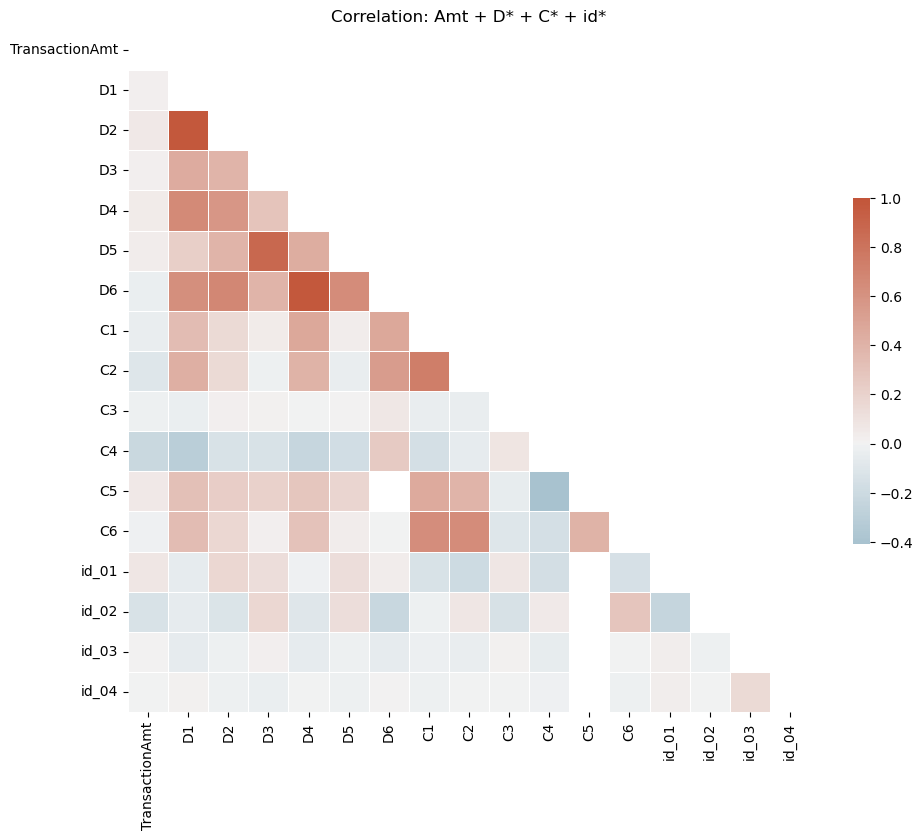

In [25]:
# Choose a small numeric subset
subset_cols = ['TransactionAmt']

subset_cols += [c for c in train.columns if c.startswith('D')][:6]   # D1-D6
subset_cols += [c for c in train.columns if c.startswith('C')][:6]   # C1-C6
subset_cols += [c for c in train.columns if c.startswith('id_')][:4] # id_01-id_04

subset_cols = list(dict.fromkeys([c for c in subset_cols if c in train.columns]))  # unique, existing

print("Subset columns for correlation:", subset_cols)

# Drop rows with all-NaN in these columns
corr_df = train[subset_cols].dropna(how='all')

corr = corr_df.corr(method='spearman')
plot_corr_heatmap(corr, title="Correlation: Amt + D* + C* + id*", vmax=1.0)

### 8.3 Block wise correlation for V-features (and how to use it to drop redundant ones) ###
The V‑features are many and often highly correlated. A common approach is:
- Work on them in blocks (e.g. V1–V50, V51–V100) to keep heatmaps readable.
- For each block, calculate correlations and identify groups of highly correlated features (e.g. |ρ| > 0.9).
- Later, keep only one feature per highly‑correlated group to reduce redundancy.

V-block 1-50: 50 columns


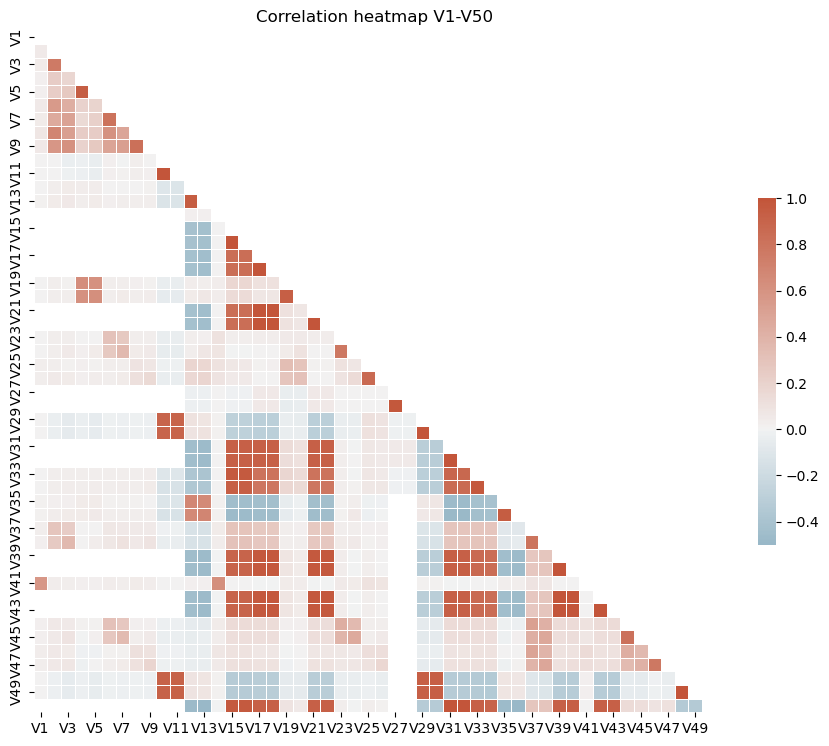

In [26]:
# 1) Plot heatmap for a block
def plot_v_block_corr(train, start=1, end=50):
    v_cols = [f"V{i}" for i in range(start, end+1) if f"V{i}" in train.columns]
    print(f"V-block {start}-{end}: {len(v_cols)} columns")
    if not v_cols:
        return None

    # Sample rows for speed
    sample = train[v_cols].sample(50000, random_state=42)
    corr = sample.corr(method='spearman')
    plot_corr_heatmap(corr, title=f"Correlation heatmap V{start}-V{end}", vmax=1.0)
    return corr

corr_v1_50 = plot_v_block_corr(train, 1, 50)
#  explore others later:
# corr_v51_100 = plot_v_block_corr(train, 51, 100)

In [28]:
# 2) Identify highly correlated V‑feature groups
#This is useful for feature reduction later
def find_high_corr_groups(corr, threshold=0.9):
    # corr is a DataFrame of correlations for one block of features
    cols = corr.columns
    visited = set()
    groups = []

    for col in cols:
        if col in visited:
            continue
        # Find features strongly correlated with this one
        high_corr = corr.index[corr[col].abs() > threshold].tolist()
        if len(high_corr) > 1:
            groups.append(high_corr)
            visited.update(high_corr)
        else:
            visited.add(col)

    return groups

# Example on the V1-50 block
if corr_v1_50 is not None:
    v_groups = find_high_corr_groups(corr_v1_50, threshold=0.9)
    print(f"Found {len(v_groups)} highly correlated groups in V1-50")
    for g in v_groups[:5]:
        print(g)

Found 8 highly correlated groups in V1-50
['V4', 'V5']
['V10', 'V11', 'V29', 'V30', 'V48', 'V49']
['V12', 'V13']
['V15', 'V16', 'V31', 'V32', 'V33', 'V34', 'V50']
['V17', 'V18', 'V21', 'V22', 'V31', 'V32', 'V39', 'V40', 'V42', 'V43', 'V50']


### 8.4 Correlation with the target( isFraud) for feature screening
Rather than only feature–feature correlation, it is helpful to see which numeric variables correlate most (even weakly) with isFraud
This gives a ranked list we can reference in our report: e.g., “D1, Vxxx, and C1 showed the strongest (though still modest) correlation with the fraud label.”

Top 20 positively correlated with isFraud:
V244    0.404460
V246    0.398693
V242    0.395531
V243    0.389075
V257    0.387434
V258    0.385553
V187    0.356946
V190    0.351649
V199    0.343503
V186    0.342284
V232    0.316612
V274    0.313596
V233    0.311725
V275    0.308356
V231    0.299720
V273    0.296365
V230    0.286948
V201    0.282981
V229    0.281454
V219    0.276900
Name: isFraud, dtype: float64

Top 20 negatively correlated with isFraud:
V35     -0.078724
D15     -0.080501
D10     -0.086074
C9      -0.093484
id_07   -0.096066
C5      -0.105389
V69     -0.108287
V70     -0.108398
V30     -0.110511
V29     -0.111120
D2      -0.111185
V91     -0.113830
V90     -0.114159
V49     -0.118202
D3      -0.118305
V48     -0.118977
id_01   -0.121786
D5      -0.165162
D8      -0.196630
D7      -0.198858
Name: isFraud, dtype: float64


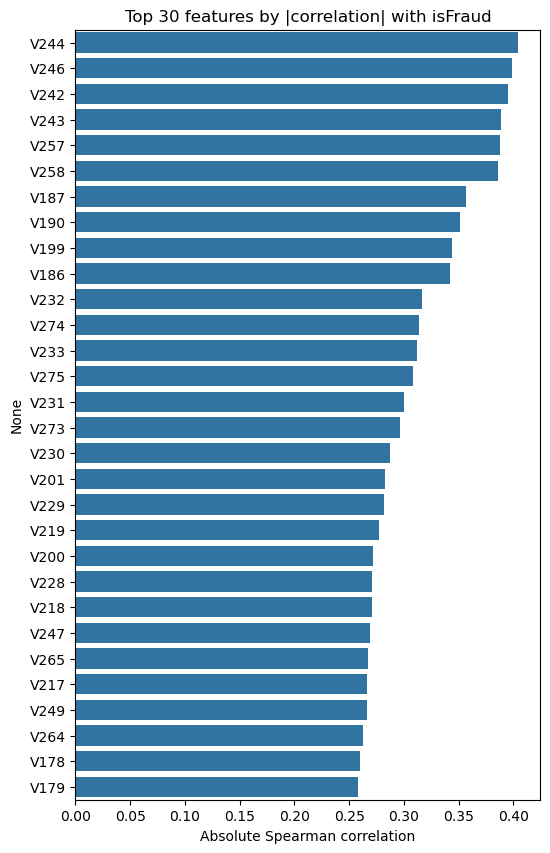

In [30]:
# Compute correlation of numeric features with isFraud
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'isFraud']

corr_target = train[numeric_cols + ['isFraud']].corr(method='spearman')['isFraud'].drop('isFraud')
corr_target = corr_target.sort_values(ascending=False)

print("Top 20 positively correlated with isFraud:")
print(corr_target.head(20))

print("\nTop 20 negatively correlated with isFraud:")
print(corr_target.tail(20))

# Plot the top 30 by absolute correlation
top_n = 30
top_abs = corr_target.abs().sort_values(ascending=False).head(top_n)

plt.figure(figsize=(6,10))
sns.barplot(x=top_abs.values, y=top_abs.index)
plt.title(f"Top {top_n} features by |correlation| with isFraud")
plt.xlabel("Absolute Spearman correlation")
plt.savefig(f"images/Top_{top_n}_FeaturesBy_correlation_with_isFraud.png")
plt.show()

## 9. First-pass feature engineering scaffolding (without modelling) ##
Here we start implementing the main feature ideas you mentioned, which you will refine later when you build models.
We don’t need to keep all engineered features; EDA helps you decide which ones are meaningful and stable.

### 9.1 Create Engineered features ###

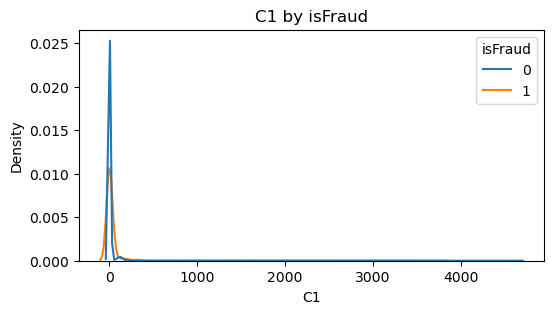

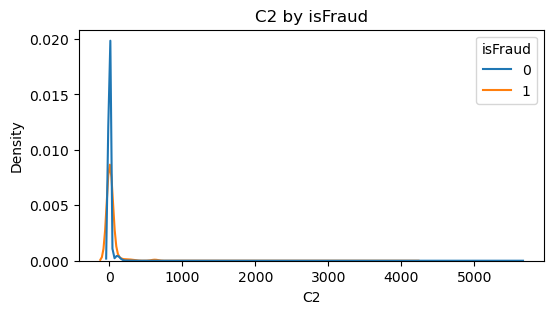

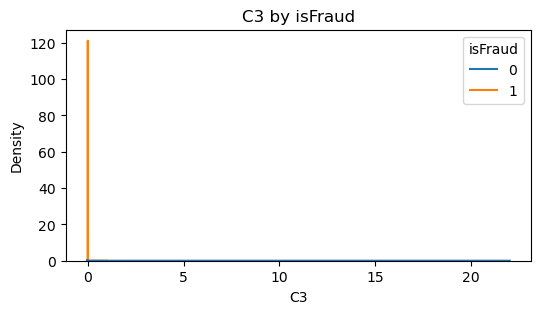

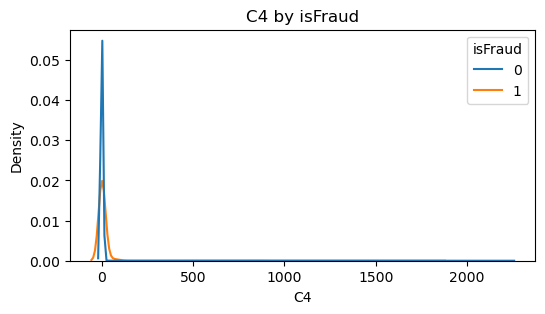

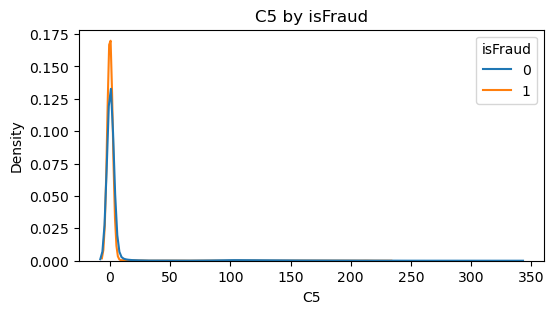

Engineered feature count: 14


['log_TransactionAmt',
 'is_weekend',
 'card1_count',
 'card1_fraud_rate',
 'card4_count',
 'card4_fraud_rate',
 'card6_count',
 'card6_fraud_rate',
 'P_emaildomain_count',
 'P_emaildomain_fraud_rate',
 'R_emaildomain_count',
 'R_emaildomain_fraud_rate',
 'DeviceType_count',
 'DeviceType_fraud_rate']

In [31]:
# Work on a copy to avoid clutter
fe = train.copy()

# 1. Log transform amount
fe['log_TransactionAmt'] = np.log1p(fe['TransactionAmt'])

# 2. Time‑based features
if 'TransactionDT_day' not in fe.columns:
    fe['TransactionDT_days'] = fe['TransactionDT'] / (24*60*60)
    fe['TransactionDT_day'] = fe['TransactionDT_days'].astype(int)
    fe['TransactionDT_hour'] = (fe['TransactionDT'] // 3600) % 24

fe['is_weekend'] = fe['TransactionDT_day'] % 7 >= 5

# 3. Simple count + risk encoding for some high‑value categoricals
risk_cols = ['card1', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType']

for col in risk_cols:
    if col in fe.columns:
        counts = fe[col].value_counts()
        fe[f'{col}_count'] = fe[col].map(counts)

        # Risk: historical fraud rate per category
        fr = fe.groupby(col)['isFraud'].mean()
        fe[f'{col}_fraud_rate'] = fe[col].map(fr)

# 4. Example of C and D aggregates
for col in [c for c in fe.columns if c.startswith('C')][:5]:
    plt.figure(figsize=(6,3))
    sns.kdeplot(data=fe.sample(100000, random_state=42), x=col, hue='isFraud', common_norm=False)
    plt.title(f"{col} by isFraud")
    plt.savefig(f"images/{col}_by_isFraud.png")
    plt.show()
    
# 5. Inspect new columns - Save a feature list for later modelling
new_features = [c for c in fe.columns if c not in train.columns]
print("Engineered feature count:", len(new_features))
new_features[:20]

### 9.2 Decide of columns to drop later ###

In [32]:
high_missing = missing_train[missing_train > 0.90].index.tolist()
print("Features with > 90% missing:", len(high_missing))

# Example: ID-like features (you will refine this)
id_like = ['TransactionID']  # add more if you identify them in EDA

drop_candidates = set(high_missing + id_like)
len(drop_candidates), list(drop_candidates)[:20]

Features with > 90% missing: 12


(13,
 ['id_25',
  'TransactionID',
  'id_24',
  'id_23',
  'id_22',
  'id_07',
  'id_21',
  'dist2',
  'D7',
  'id_18',
  'id_26',
  'id_08',
  'id_27'])